### Загрузка и обработка данных

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))

import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from Modules.panel_utils import (
    detect_outlier_regions_iqr,
    run_panel_unit_root_tests,
)
from Modules.seasonal_adjustment import (
    run_friedman_seasonality_tests,
)

In [2]:
import atexit
import shutil

temp_files = []

def cleanup():
    for file in temp_files:
        try:
            os.remove(file)
        except Exception as e:
            print(f"Ошибка при удалении файла {file}: {e}")

atexit.register(cleanup)

<function __main__.cleanup()>

In [3]:
################################
#ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
################################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')

mon_schock = 'mon_shock_dataset.pkl'
new_clustering = 'region_cluster_final.pkl'

with open(mon_schock, 'rb') as f:
    df_shocks = pickle.load(f)
with open(new_clustering, 'rb') as f:
    df_region_cluster_new = pickle.load(f)
    
# Преобразование даты 
df_shocks['Date'] = pd.to_datetime(df_shocks['Date'])
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Date'])
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

df_reg = df_reg.sort_values(['Date'])

df_reg = df_reg[~df_reg['Region'].isin(['Республика Крым','г. Севастополь'])]

In [4]:
df_region_cluster_new['Region']

0                     Алтайский край
1                   Амурская область
2              Архангельская область
3               Астраханская область
4               Белгородская область
                   ...              
76    Чувашская Республика - Чувашия
77        Чукотский автономный округ
78               Ярославская область
79                         г. Москва
80                г. Санкт-Петербург
Name: Region, Length: 75, dtype: str

In [5]:
set([x for x in list(df_reg['Region']) if x not in list(df_region_cluster_new['Region'])])

{'Республика Адыгея',
 'Республика Дагестан',
 'Республика Ингушетия',
 'Республика Тыва',
 'Чеченская Республика'}

In [6]:
###############################
# АНАЛИЗ ПАНЕЛЬНЫХ ДАННЫХ
###############################

# !!!!!!!!! ПОЧИСТИТЬ ДАННЫЕ ПО КЛАСТЕРАМ !!!!!!!!!!!!!!!!

#  ДОБАВЛЯЕМ КЛАСТЕРЫ 
df_reg = df_reg.merge(df_region_cluster_new, on='Region', how='left')

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============
df_reg = df_reg.merge(df_shocks[['Date', 'Mon_Shock']], on='Date', how='left')

df_RF.rename(columns={'exc_rate': 'Exc_rate', 'exc_rate_diff': 'd_Ex_Rate'}, inplace=True)

df_rf_extra = df_RF[['Date', 'ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum','Inflation_Expectations',
                'REER', 'Oil_p', 'MaP_Fact', 'MaP_Announcement',
                'Mortgage_MaP_Fact', 'Mortgage_MaP_Announcement',
                'Conscred_MaP_Fact', 'Conscred_MaP_Announcement',
                'MaP_Tight_Fact', 'MaP_Ease_Fact',
                'MaP_Tight_Announcement', 'MaP_Ease_Announcement',
                'Mortgage_MaP_Tight_Fact', 'Mortgage_MaP_Ease_Fact',
                'Mortgage_MaP_Tight_Announcement', 'Mortgage_MaP_Ease_Announcement',
                'Conscred_MaP_Tight_Fact', 'Conscred_MaP_Ease_Fact',
                'Conscred_MaP_Tight_Announcement', 'Conscred_MaP_Ease_Announcement']].copy()

                     
df_reg = df_reg.merge(df_rf_extra, on='Date', how='left')
df_reg.rename(columns={'CPI': 'CPI_reg'}, inplace=True)

# Приведение инфляции в регионах к обычному YoY
df_reg['CPI_reg'] = df_reg['CPI_reg'] - 100

# Создаем лаги
df_reg['Fin_Dostup_lag1'] = df_reg.groupby('Region')['Fin_Dostup'].shift(1)
df_reg['CPI_reg_lag1'] = df_reg.groupby('Region')['CPI_reg'].shift(1)
df_reg['Def_Zadolg_Fl_lag1'] = df_reg.groupby('Region')['Def_Zadolg_Fl'].shift(1)
df_reg['Def_Zadolg_Mort_lag1'] = df_reg.groupby('Region')['Def_Zadolg_Mort'].shift(1)
df_reg['Def_Zadolg_ConsCred_lag1'] = df_reg.groupby('Region')['Def_Zadolg_ConsCred'].shift(1)
df_reg['Cap_to_assets_lag1'] = df_reg.groupby('Region')['Cap_to_assets'].shift(1)

### Преобразование данных

In [7]:
# Сортировка
df_reg = df_reg.sort_values(['Region', 'Date']).copy()
df_RF = df_RF.sort_values(['Date']).copy()

# ============ ЛОГАРИФМИРОВАНИЕ ============ #

loan_vars = ['New_Loans_Fl', 'New_Loans_ConsCred', 'New_Loans_Mort', 'Fin_Dostup'] 

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])
        
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]


# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ  ============ #

# Разности для логарифмов 
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

################################
# Разности переменных регионов #
################################

diff_vars_reg = ['Int_Rate_FL', 'Int_Rate_Mort', 'Int_Rate_ConsCred', 'Int_Rate_Mort', 'Int_Rate_Progr_DOMRF',
            'Mon_Shock', 'ROISFIX', 'MIACR',
            'ln_New_Loans_Fl', 'ln_New_Loans_ConsCred', 'ln_New_Loans_Mort', ] 

d_rf_vars = list()
for var in diff_vars_reg:
    d_var = f'd_{var}'
    d_rf_vars.append(d_var)
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

#################################
# Разности федеральных переменных
#################################

df_RF = df_RF.sort_values(['Date'])

diff_vars_fed = ['Key_Rate', 'ROISFIX', 'MIACR']

for var in diff_vars_fed:
    d_var = f'd_{var}'
    df_RF[d_var] = df_RF[var].diff()


# Разделим шоки на позитивные и негативные
# Mon_Shock
df_reg['d_Mon_Shock_neg'] = df_reg['d_Mon_Shock'].where(df_reg['d_Mon_Shock'] < 0, 0)
df_reg['d_Mon_Shock_pos'] = df_reg['d_Mon_Shock'].where(df_reg['d_Mon_Shock'] > 0, 0)
# Разность ROISFIX 
df_reg['d_ROISFIX_neg'] = df_reg['d_ROISFIX'].where(df_reg['d_ROISFIX'] < 0, 0)
df_reg['d_ROISFIX_pos'] = df_reg['d_ROISFIX'].where(df_reg['d_ROISFIX'] > 0, 0)
# Разность MIACR 
df_reg['d_MIACR_neg'] = df_reg['d_MIACR'].where(df_reg['d_MIACR'] < 0, 0)
df_reg['d_MIACR_pos'] = df_reg['d_MIACR'].where(df_reg['d_MIACR'] > 0, 0)

d_rf_vars = d_rf_vars + ['Mon_Shock', 'd_Mon_Shock_neg', 'd_Mon_Shock_pos', 'd_ROISFIX_neg', 'd_ROISFIX_pos', 'd_MIACR_neg', 'd_MIACR_pos',]

#  Создаем взаимодействия для переменных процентных ставок
map_vars_int = ['d_Mon_Shock',
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR',
    'd_MIACR_neg',
    'd_MIACR_pos',
]

z_vars_int = [
    'Covid_dum',
    'Sank_dum',
    'Cluster_new_cd_1',
    'Cluster_new_cd_3',
    'Cluster_new_cd_4',
]

z_cols_int = list()
for m in map_vars_int:
    for z in z_vars_int:
        col_name = f"{m}_{z}"
        z_cols_int.append(col_name)
        df_reg[col_name] = df_reg[m] * df_reg[z]


#  Создаем взаимодействия для переменных макропру
map_var_makro = [
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
]

z_vars_makro = [
    'Fin_Dostup_lag1',
    'Cap_to_assets_lag1',
    'Cluster_new_cd_1',
    'Cluster_new_cd_3',
    'Cluster_new_cd_4',
]

z_cols_makro = list()
for m in map_var_makro:
    for z in z_vars_makro:
        col_name = f"{m}_{z}"
        z_cols_makro.append(col_name)
        df_reg[col_name] = df_reg[m] * df_reg[z]


### IQR чистка

In [8]:
df_reg.columns[df_reg.columns.duplicated()].tolist()

[]

In [9]:
df_reg_analys = df_reg[['Region', 'Date'] + [c for c in df_reg.columns
                                            if c not in ['Num_reg', 'Region', 'Date']]].copy()
                                            
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

list_to_filter = [
    'Region', 'Date',
    # Зависимые и регрессоры без обработки
    'Fin_Dostup',
    'Int_Rate_FL',
    'Int_Rate_Mort',
    'Int_Rate_ConsCred',
    'Int_Rate_Progr_DOMRF',
    'Int_Rate_Progr',
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    'New_Loans_Progr_DOMRF',
    'New_Loans_Progr',
    # Mom
    'Zadolg_Fl_mom',
    'Zadolg_Mort_mom',
    'Zadolg_ConsCred_mom',
    'New_Loans_Fl_mom',
    'New_Loans_Mort_mom',
    'New_Loans_ConsCred_mom',
    'New_Loans_Progr_DOMRF_mom',
    'New_Loans_Progr_mom',
    # Лаги
    'D_top5_rozn',
    'CPI_reg_lag1',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    # Mакроэкономический
    'Credit_impulse',
    'Share_mining',
    # Кластеры 
    'Cluster_1', 
    'Cluster_HANK_1',
    'Cluster_HANK_2',
    'Cluster_HANK_3',
    'Cluster_new_cd_1', # Их 4
    'Cluster_new_cd_3',
    'Cluster_new_cd_4',
    # Неиспользуется
    'd_ln_Fin_Dostup',
    # Противные переменные
    'New_Loans_Progr',
    'New_Loans_Progr_DOMRF',
    'ln_New_Loans_Progr_DOMRF',
    'New_Loans_Progr_mom',
    'Int_Rate_Progr',
    'New_Loans_Progr_DOMRF_mom',
    ] + list(df_RF.columns)[3:] + d_rf_vars + z_cols_int + z_cols_makro


key_vars = [x for x in list(df_reg_analys.columns) if x not in list_to_filter]

# Проверка датафрейма дюпликаты
df_reg_analys = df_reg_analys.loc[:, ~df_reg_analys.columns.duplicated()]
key_vars = list(dict.fromkeys(key_vars))  # preserve order, remove duplicates

# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# СОХРАНЕНИЕ СПИСКА РЕГИОНОВ
with Path('filter_for_cluster.pkl').open("wb") as saved:
    pickle.dump(good_regions_iqr, saved)

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys = df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")
df_reg_analys.columns[df_reg_analys.columns.duplicated()].tolist()



ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 80 РЕГИОНОВ (IQR)
                             Region  N_obs NA_pct  IQR_outliers IQR_pct Bad_Indicators Indicator_Problem Reasons Status
                     Алтайский край     82   2.4%             3    3.7%                                            KEEP
                   Амурская область     82   2.4%             0    0.0%                                            KEEP
              Архангельская область     82   2.4%             7    8.5%                                            KEEP
               Астраханская область     82   2.4%             0    0.0%                                            KEEP
               Белгородская область     82   2.4%             0    0.0%                                            KEEP
                   Брянская область     82   2.4%             0    0.0%                                            KEEP
               Владимирская область     82   2.4%             1    1.2%                              

[]

### Выбор переменных

In [10]:
df_reg_analys[key_vars].select_dtypes(exclude='number').columns

Index([], dtype='str')

In [11]:
list(df_reg_analys.columns)

['Region',
 'Date',
 'D_top5_rozn',
 'Zakred',
 'Zadolg_Fl',
 'Zadolg_Mort',
 'Zadolg_ConsCred',
 'Def_Zadolg_Fl',
 'Def_Zadolg_Mort',
 'Def_Zadolg_ConsCred',
 'New_Loans_Fl',
 'New_Loans_Mort',
 'New_Loans_ConsCred',
 'Int_Rate_FL',
 'Int_Rate_Mort',
 'Int_Rate_ConsCred',
 'Int_Rate_Progr_DOMRF',
 'Fin_Dostup',
 'CPI_reg',
 'Cap_to_assets',
 'Credit_load_Mort',
 'Cred_nagr',
 'Cluster_new_cd_1',
 'Cluster_new_cd_3',
 'Cluster_new_cd_4',
 'Mon_Shock',
 'ROISFIX',
 'MIACR',
 'Covid_dum',
 'Sank_dum',
 'Inflation_Expectations',
 'REER',
 'Oil_p',
 'MaP_Fact',
 'MaP_Announcement',
 'Mortgage_MaP_Fact',
 'Mortgage_MaP_Announcement',
 'Conscred_MaP_Fact',
 'Conscred_MaP_Announcement',
 'MaP_Tight_Fact',
 'MaP_Ease_Fact',
 'MaP_Tight_Announcement',
 'MaP_Ease_Announcement',
 'Mortgage_MaP_Tight_Fact',
 'Mortgage_MaP_Ease_Fact',
 'Mortgage_MaP_Tight_Announcement',
 'Mortgage_MaP_Ease_Announcement',
 'Conscred_MaP_Tight_Fact',
 'Conscred_MaP_Ease_Fact',
 'Conscred_MaP_Tight_Announcement',
 'Co

In [12]:
# СПИСОК ПЕРЕМЕННЫХ
all_vars = {
'conscred_vars' : [
    #Блок 1 - Зависимые переменные 
    'd_Int_Rate_ConsCred',          # Зависимая переменная
    'Int_Rate_ConsCred',
    #Блок 2 - Переменные портфеля 
    'd_ln_New_Loans_ConsCred',           # Выдача
    'd_ln_New_Loans_Fl',
    'Zadolg_ConsCred',              # Задолженность
    'Zadolg_Fl',
    'Def_Zadolg_ConsCred',          # Дефицит задолж
    'Def_Zadolg_Fl',
    #Блок 3 - Характеристики фин системы
    'Cap_to_assets',
    'ln_Fin_Dostup',
    'D_top5_rozn',
    'Zakred',
    'Cred_nagr',
    #Блок 4 - Макроэкономический
    'Inflation_Expectations',
    'CPI_reg',
    'REER',
    #Блок 5 - Монетарный 
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR_neg',
    'd_MIACR_pos',
    #Блок 6 - Кластеры
    'Cluster_new_cd_1',
    'Cluster_new_cd_3',
    'Cluster_new_cd_4',
    #Блок 7 - Шоки
    'Covid_dum',
    'Sank_dum',
],

'fl_cred_vars' : [
    #Блок 1 - Зависимые переменные 
    'd_Int_Rate_FL',          # Зависимая переменная
    'Int_Rate_FL',
    #Блок 2 - Переменные портфеля 
    'd_ln_New_Loans_Fl',            # Выдача
    'Zadolg_Fl',                    # Задолженность
    'Def_Zadolg_Fl',                # Дефицит задолж
    #Блок 3 - Характеристики фин системы
    'Cap_to_assets',
    'ln_Fin_Dostup',
    'D_top5_rozn',
    'Zakred',
    'Cred_nagr',
    #Блок 4 - Макроэкономический
    'Inflation_Expectations',
    'CPI_reg',
    'REER',
    #Блок 5 - Монетарный 
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR_neg',
    'd_MIACR_pos',
    #Блок 6 - Кластеры
    'Cluster_new_cd_1',
    'Cluster_new_cd_3',
    'Cluster_new_cd_4',
    #Блок 7 - Шоки
    'Covid_dum',
    'Sank_dum',
],

'mortgage_cred_vars' : [
    #Блок 1 - Зависимые переменные 
    'd_Int_Rate_Mort',
    'd_Int_Rate_Progr_DOMRF',
    #Блок 2 - Переменные портфеля 
    'd_ln_New_Loans_Fl',            # Выдача
    'Zadolg_Fl',                    # Задолженность
    'Def_Zadolg_Fl',                # Дефицит задолж
    #Блок 2.5 - Переменные ипотеки
    'd_ln_New_Loans_Mort',
    'Credit_load_Mort',
    #Блок 3 - Характеристики фин системы
    'Cap_to_assets',
    'ln_Fin_Dostup',
    'D_top5_rozn',
    'Zakred',
    'Cred_nagr',
    #Блок 4 - Макроэкономический
    'Inflation_Expectations',
    'CPI_reg',
    'REER',
    #Блок 5 - Монетарный 
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR_neg',
    'd_MIACR_pos',
    #Блок 6 - Кластеры
    'Cluster_new_cd_1',
    'Cluster_new_cd_3',
    'Cluster_new_cd_4',
    #Блок 7 - Шоки
    'Covid_dum',
    'Sank_dum',
],

'exog_vars' : [
    #Блок 1 - Зависимые переменные 
    'd_ln_New_Loans_Fl',
    'd_ln_New_Loans_Mort',
    'd_ln_New_Loans_ConsCred',
    #Блок 2 - Переменные интереса 
    'MaP_Fact',
    'MaP_Announcement',
    'MaP_Tight_Fact', 
    'MaP_Ease_Fact',
    'MaP_Tight_Announcement', 
    'MaP_Ease_Announcement',
    'Mortgage_MaP_Fact',
    'Mortgage_MaP_Announcement',
    'Mortgage_MaP_Tight_Fact', 
    'Mortgage_MaP_Ease_Fact',
    'Mortgage_MaP_Tight_Announcement', 
    'Mortgage_MaP_Ease_Announcement',
    'Conscred_MaP_Fact', 
    'Conscred_MaP_Announcement',
    'Conscred_MaP_Tight_Fact', 
    'Conscred_MaP_Ease_Fact',
    'Conscred_MaP_Tight_Announcement',
    'Conscred_MaP_Ease_Announcement',
    #Блок 3 - характеристики фин системы
    'Fin_Dostup_lag1',
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    'Credit_load_Mort', # сложность выплаты ипотеки
    'Cred_nagr',
    #Блок 4 - макроэкономический
    'CPI_reg_lag1',
    'Oil_p',
    'REER',
    #Блок 5 - монетарный 
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR_neg',
    'd_MIACR_pos',
    #Блок 6 - кластеры
    'Cluster_new_cd_1',
    'Cluster_new_cd_3',
    'Cluster_new_cd_4',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum'
],
}                                                                                                                                                                                                                                                                                                                                                                                                                                           
choosed_vars = all_vars['exog_vars']
name = [key for key, value in all_vars.items() if value == choosed_vars][0][:-5]

df_reg_analys = df_reg_analys[['Region', 'Date'] + choosed_vars].copy()
cols_for_drop = [c for c in df_reg_analys.columns if c not in ['New_Loans_Progr']]
df_reg_analys = df_reg_analys.dropna(subset=cols_for_drop)

### ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ

In [13]:
descriptive_df = df_reg_analys.drop(columns=['Date', 'Region',], axis = 0, inplace=False)#'Int_Rate_ConsCred_lag1'


desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                                 Среднее  Медиана  ст. откл.    Мин.   Макс.
d_ln_New_Loans_Fl                  0.012    0.042      0.169  -0.936   0.738
d_ln_New_Loans_Mort                0.019    0.078      0.362  -1.826   1.162
d_ln_New_Loans_ConsCred            0.010    0.027      0.147  -0.973   0.814
MaP_Fact                           0.145    0.000      0.518  -1.000   1.000
MaP_Announcement                   0.145    0.000      0.541  -1.000   1.000
MaP_Tight_Fact                     0.241    0.000      0.428   0.000   1.000
MaP_Ease_Fact                     -0.096    0.000      0.295  -1.000   0.000
MaP_Tight_Announcement             0.253    0.000      0.435   0.000   1.000
MaP_Ease_Announcement             -0.108    0.000      0.311  -1.000   0.000
Mortgage_MaP_Fact                  0.036    0.000      0.327  -1.000   1.000
Mortgage_MaP_Announcement          0.048    0.000      0.408  -1.000   1.000
Mortgage_MaP_Tight_Fact

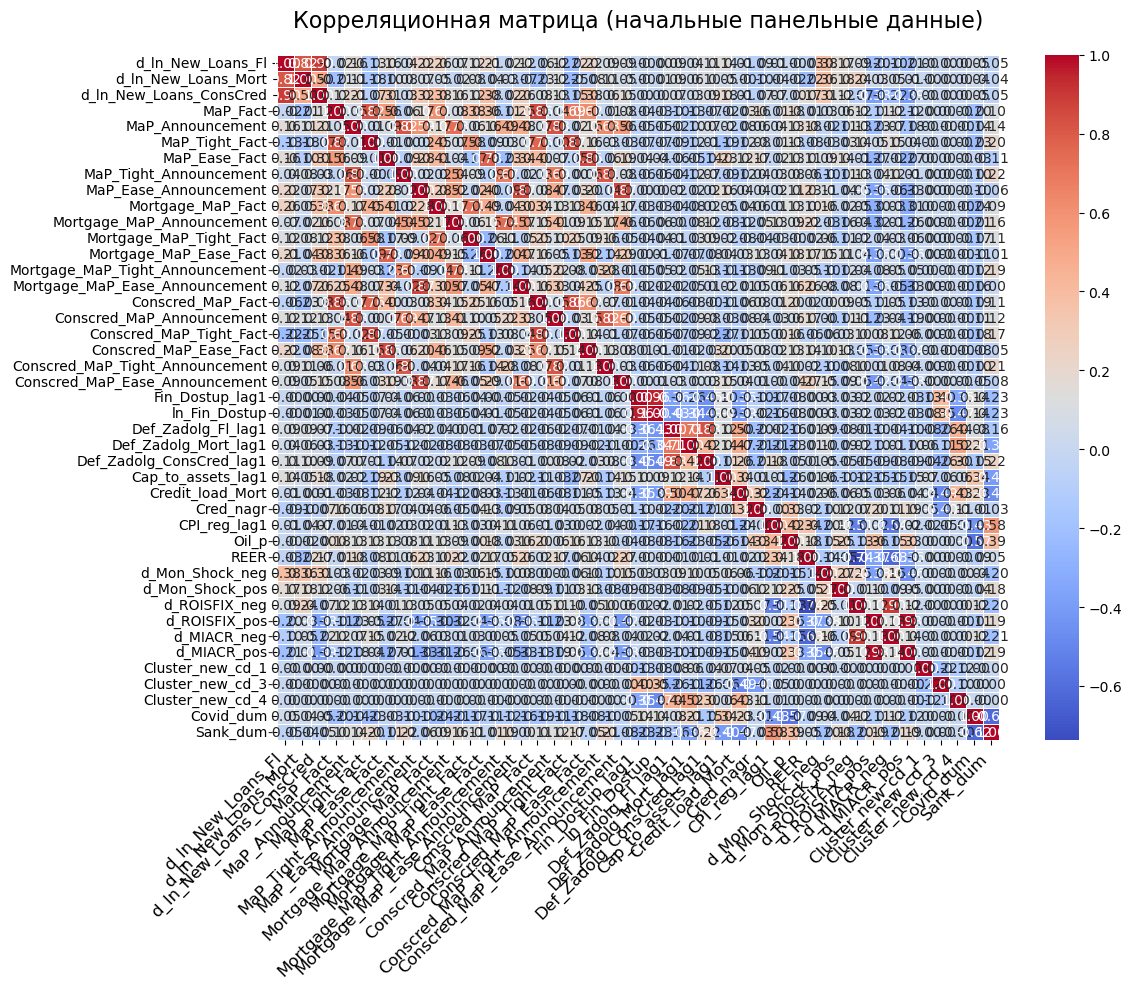

In [14]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

### Тест Фридмана на сезонность

In [15]:
res = run_friedman_seasonality_tests(df_RF, date_col='Date')


РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                       Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
                        ROISFIX     1.666667 0.999366            False        6        12
         Inflation_Expectations    19.898007 0.046759             True        6        12
           Nominal_Percent_Rate    11.566303 0.397109            False        6        12
                          MIACR     1.879300 0.998877            False        6        12
                          Oil_p     6.435897 0.842756            False        6        12
                            CPI     7.457410 0.760925            False        6        12
                           REER    18.429656 0.072132            False        6        12
                       Key_Rate     0.741978 0.999989            False        6        12
            Ent_conf_ind_mining     8.051613 0.708673            False        6        12
     Ent_conf_ind_manufactoring     3.872876 0.973489            False  

In [16]:
# # Extra diagnostics after Friedman test
# from Modules.seasonal_adjustment import run_seasonal_diagnostics

# series_list = [
#     'Inflation_Expectations',
#     'Ent_conf_ind_mining',
#     'Ent_conf_ind_manufactoring'
# ]

# for col in series_list:
#     if col in df_RF.columns:
#         run_seasonal_diagnostics(df_RF, 'Date', col, shock_year="2022")
#     else:
#         print(f'Missing column: {col}')


# # ####################################
# # # Сезонность есть даже с учётом шока в: Inflation_Expectations, Ent_conf_ind_manufactoring

### ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====

In [17]:
df_reg_analys.columns

Index(['Region', 'Date', 'd_ln_New_Loans_Fl', 'd_ln_New_Loans_Mort',
       'd_ln_New_Loans_ConsCred', 'MaP_Fact', 'MaP_Announcement',
       'MaP_Tight_Fact', 'MaP_Ease_Fact', 'MaP_Tight_Announcement',
       'MaP_Ease_Announcement', 'Mortgage_MaP_Fact',
       'Mortgage_MaP_Announcement', 'Mortgage_MaP_Tight_Fact',
       'Mortgage_MaP_Ease_Fact', 'Mortgage_MaP_Tight_Announcement',
       'Mortgage_MaP_Ease_Announcement', 'Conscred_MaP_Fact',
       'Conscred_MaP_Announcement', 'Conscred_MaP_Tight_Fact',
       'Conscred_MaP_Ease_Fact', 'Conscred_MaP_Tight_Announcement',
       'Conscred_MaP_Ease_Announcement', 'Fin_Dostup_lag1', 'ln_Fin_Dostup',
       'Def_Zadolg_Fl_lag1', 'Def_Zadolg_Mort_lag1',
       'Def_Zadolg_ConsCred_lag1', 'Cap_to_assets_lag1', 'Credit_load_Mort',
       'Cred_nagr', 'CPI_reg_lag1', 'Oil_p', 'REER', 'd_Mon_Shock_neg',
       'd_Mon_Shock_pos', 'd_ROISFIX_neg', 'd_ROISFIX_pos', 'd_MIACR_neg',
       'd_MIACR_pos', 'Cluster_new_cd_1', 'Cluster_new_cd_3',
    


СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Ent_conf_ind_manufactoring (Ent_conf_ind_manufactoring):
  ✓ Успешно скорректировано, снижение волатильности: 0.4%

Ent_conf_ind_mining (Ent_conf_ind_mining):
  ✓ Успешно скорректировано, снижение волатильности: 0.1%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ
✓ Ent_conf_ind_manufactoring_adj: 84 не-NaN значений
✓ Ent_conf_ind_manufactoring_trend: 84 не-NaN значений
✓ Ent_conf_ind_manufactoring_seasonal: 84 не-NaN значений
✓ Ent_conf_ind_mining_adj: 84 не-NaN значений
✓ Ent_conf_ind_mining_trend: 84 не-NaN значений
✓ Ent_conf_ind_mining_seasonal: 84 не-NaN значений

✓ Всего добавлено столбцов: 6

СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКТИРОВКИ

Федеральные переменные:
--------------------------------------------------
Переменная                     Волатильность ↓
--------------------------------------------------
Ent_conf_ind_manufactoring                0.4%
Ent_conf_ind_mining                       0.1%


Р

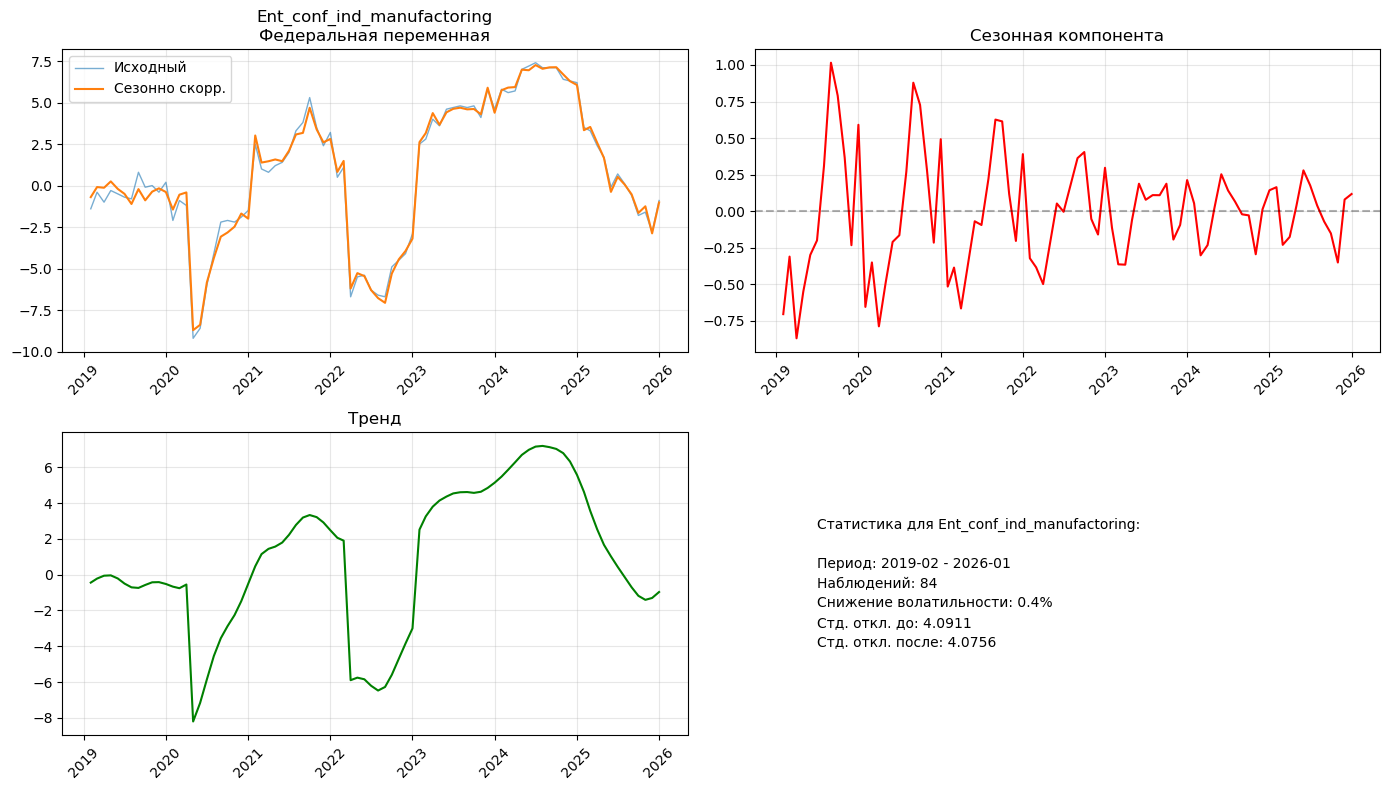

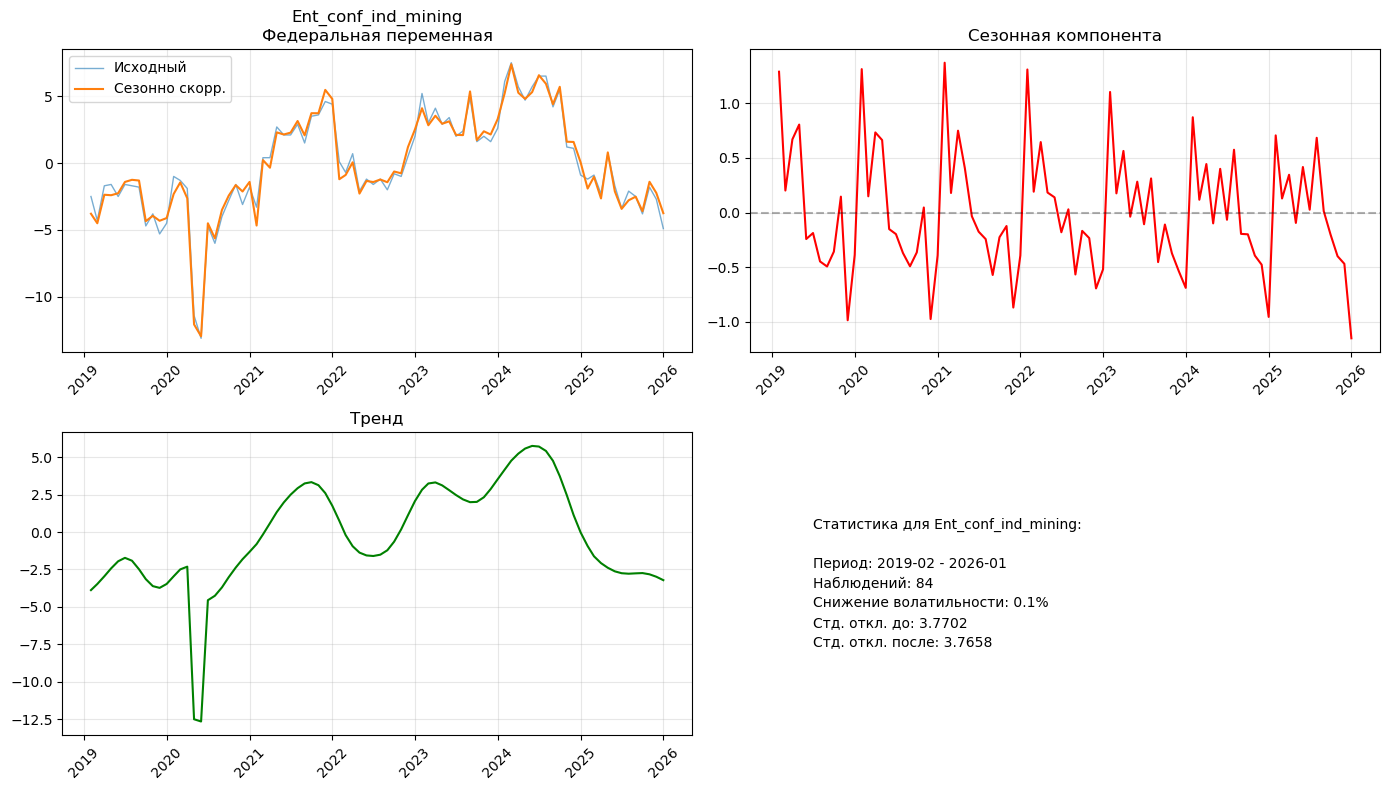


ФИНАЛЬНАЯ СТАТИСТИКА

Обработано федеральных переменных: 2/2
Обработано региональных переменных: 0/0
Общее количество добавленных столбцов: 6
Форма df: (84, 41)

Столбцов _adj: 2
Столбцов _trend: 2
Столбцов _seasonal: 2

✓ Скорректированные ряды добавлены в df
✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)


In [18]:
# Сезонная корректировка 
# ! Для корректировки НЕОБХОДИМО добавить новые переменные в список функции seasonal_adjust_panel_wrapper в seasonal_adjustment.py
# 'Inflation_Expectations', 'Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining' потенциальные переменные
# Output_Index, IBC_constr, IBC_torg, IBC_auto, IBC_constr_fed, IBC_torg_fed, IBC_auto_fed

from Modules.seasonal_adjustment import seasonal_adjust_panel_wrapper

if 'Inflation_Expectations' in list(df_reg_analys.columns):
    col_name_reg = ['Inflation_Expectations']  
    df_reg_analys = seasonal_adjust_panel_wrapper(df_reg_analys, col_name_reg)

col_name_fed = ['Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining'] 
df_RF = seasonal_adjust_panel_wrapper(df_RF, col_name_fed)


In [19]:
# Чистка датафрейма
to_delete_columns_reg = [col for col in df_reg_analys.columns if col.endswith('_seasonal') or col.endswith('_trend')]
to_delete_columns_RF = [col for col in df_RF.columns if col.endswith('_seasonal') or col.endswith('_trend')]

df_reg_analys.drop(columns=to_delete_columns_reg, inplace=True)
df_RF.drop(columns=to_delete_columns_RF, inplace=True)

# Разность инфляционных ожиданий
if 'Inflation_Expectations_adj' in df_reg_analys.columns:
    df_reg_analys['d_Inflation_Expectations'] = df_reg_analys['Inflation_Expectations_adj'].diff()

### Tестирование единичных корней

In [20]:
# # ===== ЗАПУСК ТЕСТОВ НА КОНКРЕТНЫЕ ПЕРЕМЕННЫЕ =====

# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1")
# print("="*70)

# # === СПИСОК ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
# custom_vars = [x for x in choosed_vars if x not in [
#     'Cluster_1',
#     'Cluster_2',
#     'Covid_dum',
#     'Sank_dum']
# ]

# df_reg_analys_clus_1 = df_reg_analys[df_reg_analys['Cluster_1'] == 1].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_1, panel_vars=custom_vars)

In [21]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2")
# print("="*70)


# df_reg_analys_clus_two = df_reg_analys[df_reg_analys['Cluster_2'] == 1].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_two, panel_vars=custom_vars)

In [22]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3")
# print("="*70)

# df_reg_analys_clus_three = df_reg_analys[(df_reg_analys['Cluster_1'] == 0) & (df_reg_analys['Cluster_2'] == 0)].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_three, panel_vars=custom_vars)

In [23]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ")
# print("="*70)
# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted_all = run_panel_unit_root_tests(df_reg_analys, panel_vars=custom_vars)

### Сохранение результатов

In [24]:
df_reg_analys.to_excel(f'Operations/{name}_reg_analys.xlsx')
df_RF.to_excel('Operations/fed_analys.xlsx')

print('='*95 + f'\n\n Данные сохранены в папке Operations под названиями {name}_reg_analys.xlsx и fed_analys.xlsx')


 Данные сохранены в папке Operations под названиями exog_reg_analys.xlsx и fed_analys.xlsx
